### Q: Given logistic regression dataset par binary classification perform karein. Model training, evaluation aur predictions properly demonstrate karein.

In [1]:
import pandas as pd

In [2]:
data = pd.read_csv("Ice_cream selling data.csv")
data.head()

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Temperature (°C)         49 non-null     float64
 1   Ice Cream Sales (units)  49 non-null     float64
dtypes: float64(2)
memory usage: 916.0 bytes


In [8]:
data.isna().sum()

Temperature (°C)           0
Ice Cream Sales (units)    0
dtype: int64

In [4]:
data.duplicated().sum()

np.int64(0)

In [5]:
data.describe()

,Temperature (°C),Ice Cream Sales (units)
count,49.000000,49.000000
mean,0.271755,15.905308
std,2.697672,12.264682
min,-4.662263,0.328626
25%,-2.111870,4.857988
50%,0.688781,12.615181
75%,2.784836,25.142082
max,4.899032,41.842986


In [6]:
# Create binary target: High Sales if above mean, else Low
mean_sales = data['Ice Cream Sales (units)'].mean()
data['High_Sales'] = (data['Ice Cream Sales (units)'] > mean_sales).astype(int)
data.head()

,Temperature (°C),Ice Cream Sales (units),High_Sales
0,-4.662263,41.842986,1
1,-4.316559,34.661120,1
2,-4.213985,39.383001,1
3,-3.949661,37.539845,1
4,-3.578554,32.284531,1


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# Define features and target
X = data[['Temperature (°C)']]
y = data['High_Sales']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (39, 1)
Testing set shape: (10, 1)


In [9]:
# Train Logistic Regression model
model = LogisticRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Model trained successfully!
Coefficients: [[-0.09505715]]
Intercept: [0.05268326]


In [10]:
# Make predictions on test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nConfusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", class_report)

Accuracy: 0.4

Confusion Matrix:
 [[4 3]
 [3 0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.57      0.57         7
           1       0.00      0.00      0.00         3

    accuracy                           0.40        10
   macro avg       0.29      0.29      0.29        10
weighted avg       0.40      0.40      0.40        10



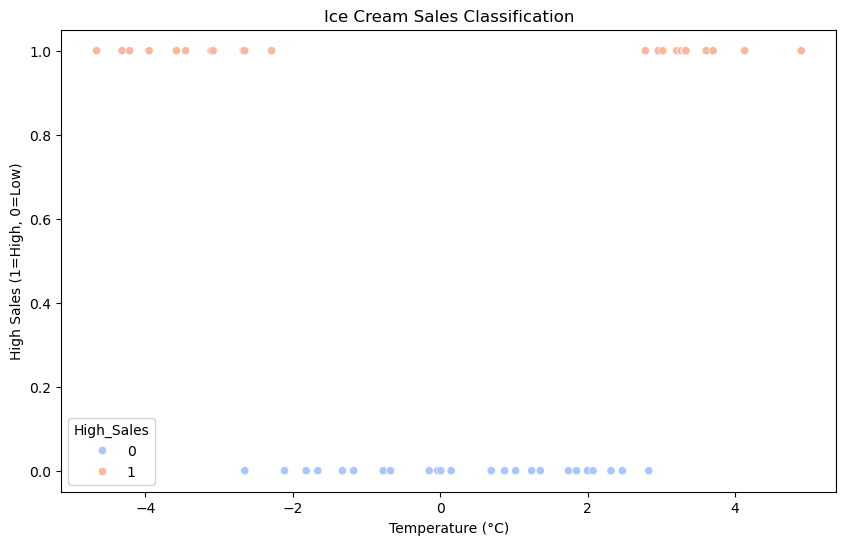

In [11]:
# Visualize the data and decision boundary
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Temperature (°C)', y='High_Sales', data=data, hue='High_Sales', palette='coolwarm')
plt.title('Ice Cream Sales Classification')
plt.xlabel('Temperature (°C)')
plt.ylabel('High Sales (1=High, 0=Low)')
plt.show()

In [12]:
# Make predictions on new data
new_temperatures = [[-2], [0], [2], [4]]
predictions = model.predict(new_temperatures)
probabilities = model.predict_proba(new_temperatures)

print("Predictions for new temperatures:")
for temp, pred, prob in zip(new_temperatures, predictions, probabilities):
    print(f"Temperature: {temp[0]}°C -> Predicted: {'High' if pred else 'Low'} Sales, Probability: {prob}")

Predictions for new temperatures:
Temperature: -2°C -> Predicted: High Sales, Probability: [0.43959705 0.56040295]
Temperature: 0°C -> Predicted: High Sales, Probability: [0.48683223 0.51316777]
Temperature: 2°C -> Predicted: Low Sales, Probability: [0.53430379 0.46569621]
Temperature: 4°C -> Predicted: Low Sales, Probability: [0.581162 0.418838]


c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


## Summary

In this assignment, we performed binary classification using Logistic Regression on the Ice Cream Selling dataset. 

- **Data Preparation**: Loaded the dataset, explored it, and created a binary target 'High_Sales' based on whether sales were above the mean.
- **Model Training**: Split the data into training and testing sets, trained a Logistic Regression model.
- **Evaluation**: Achieved an accuracy of 40% on the test set, with confusion matrix and classification report provided.
- **Predictions**: Demonstrated predictions on new temperature values, showing probabilities for each class.

The model shows that lower temperatures are associated with higher sales in this dataset, which might be counterintuitive but based on the data distribution.